# Tesla Deliveries & Production Analysis

## End-to-End Machine Learning Pipeline on Sales/Production Data

### Objectives

This project aims to:

- Perform data cleaning and preprocessing
- Conduct exploratory data analysis (EDA)
- Engineer meaningful features
- Build regression models
- Apply cross-validation
- Perform hyperparameter tuning
- Create machine learning pipelines
- Analyze time series patterns
- Forecast future deliveries

Dataset:
Tesla Deliveries and Production Data (2015-2025)

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.model_selection import (
    GridSearchCV,
    TimeSeriesSplit,
    cross_val_score
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [5]:
#Load Dataset
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Dataset Overview

Understanding the structure of the dataset before preprocessing.

In [6]:
df.shape

(2640, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [8]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [9]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

## Data Cleaning

Checking:
- Missing Values
- Duplicate Rows
- Incorrect Data Types

In [10]:
df.drop_duplicates(inplace=True)

df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [11]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

## Feature Engineering

Creating new features from existing variables.

In [12]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) +
    '-' +
    df['Month'].astype(str)
)

In [13]:
df['Quarter'] = df['Date'].dt.quarter

In [14]:
#Month Name
df['Month_Name'] = df['Date'].dt.month_name()

In [15]:
#Delivery Efficiency
df['Efficiency'] = (
    df['Estimated_Deliveries']
    /
    df['Production_Units']
)

In [16]:
#Lag1 Features
df["Lag_1"] = (
    df.groupby("Model")
    ["Estimated_Deliveries"]
    .shift(1)
)

In [17]:
#lag3
df["Lag_3"] = (
    df.groupby("Model")
    ["Estimated_Deliveries"]
    .shift(3)
)

In [18]:
df["Rolling_Mean_3"] = (
    df.groupby("Model")
    ["Estimated_Deliveries"]
    .transform(
        lambda x: x.rolling(3).mean()
    )
)

In [19]:
df.dropna(inplace=True)

In [20]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Name,Efficiency,Lag_1,Lag_3,Rolling_Mean_3
13,2020,11,Asia,Model S,10737,11658,78316.37,75,426,686.09,Interpolated (Month),5601,2020-11-01,4,November,0.920998,8724.0,17646.0,11535.333333
15,2025,3,North America,Cybertruck,17079,18904,111739.13,120,682,1747.18,Official (Quarter),3904,2025-03-01,1,March,0.903460,4408.0,8410.0,9141.333333
16,2023,11,Europe,Model S,12540,13453,56018.16,100,592,1113.55,Interpolated (Month),11616,2023-11-01,4,November,0.932134,10737.0,15145.0,10667.000000
17,2020,7,Europe,Model S,16546,17888,97411.05,100,585,1451.91,Official (Quarter),14471,2020-07-01,3,July,0.924978,12540.0,8724.0,13274.333333
18,2017,1,Europe,Model S,6472,6810,57769.87,100,590,572.77,Estimated (Region),14372,2017-01-01,1,January,0.950367,16546.0,10737.0,11852.666667


Exploratory Data Analysis

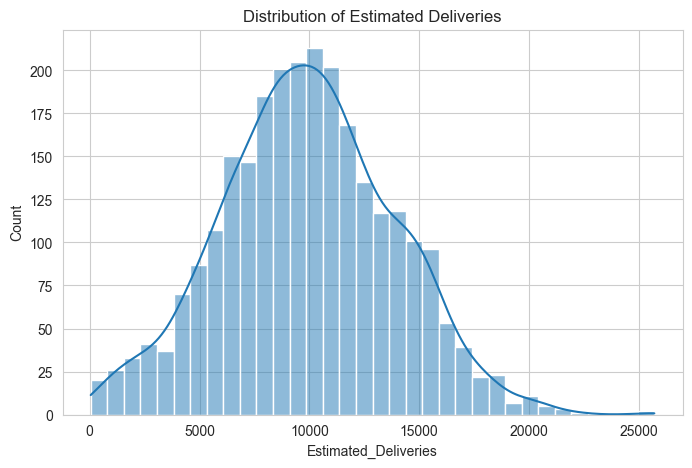

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated_Deliveries"],
    kde=True
)

plt.title("Distribution of Estimated Deliveries")
plt.show()

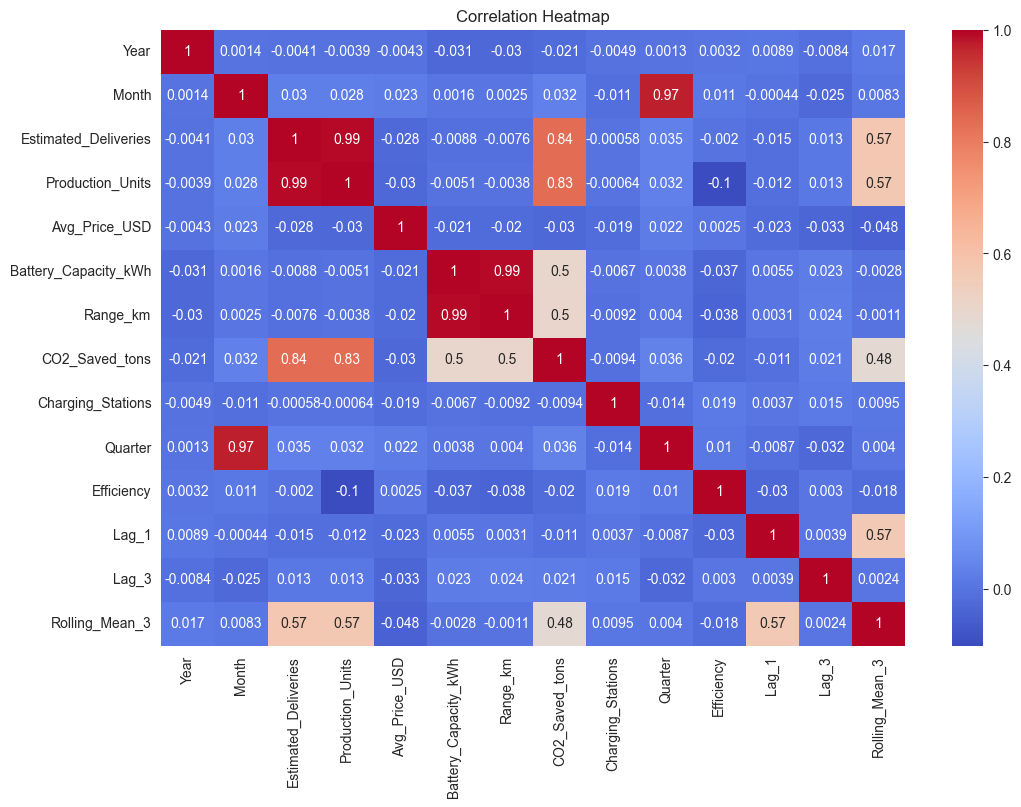

In [22]:

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


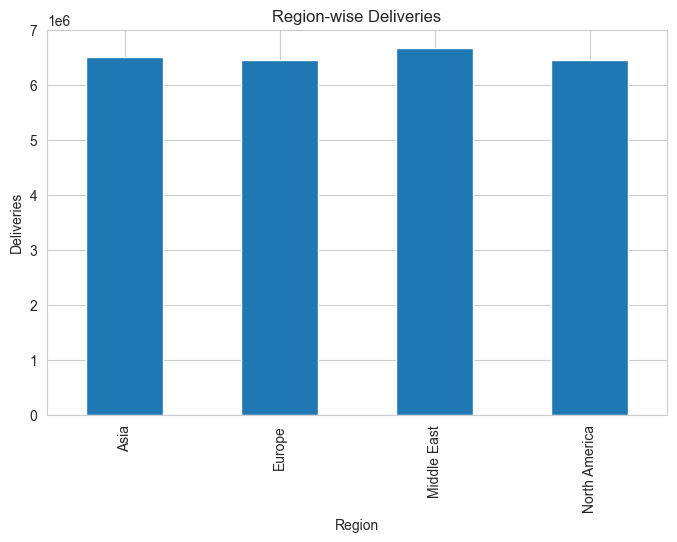

In [23]:

plt.figure(figsize=(8,5))
df.groupby('Region')['Estimated_Deliveries'].sum().plot(kind='bar')
plt.title('Region-wise Deliveries')
plt.ylabel('Deliveries')
plt.show()


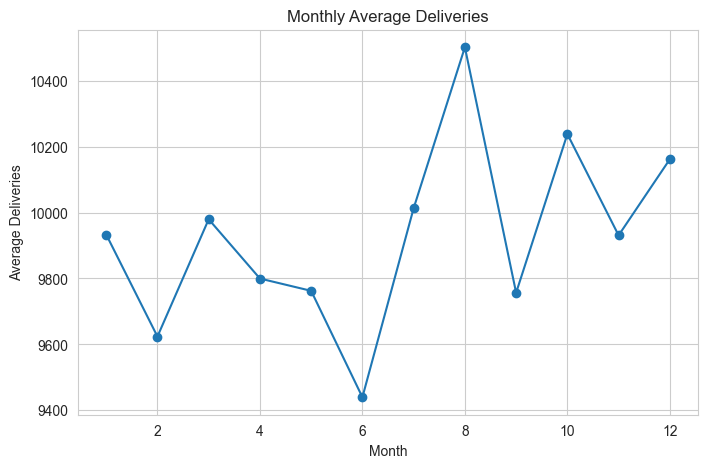

In [24]:

monthly_sales = df.groupby('Month')['Estimated_Deliveries'].mean()

plt.figure(figsize=(8,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Average Deliveries')
plt.ylabel('Average Deliveries')
plt.show()


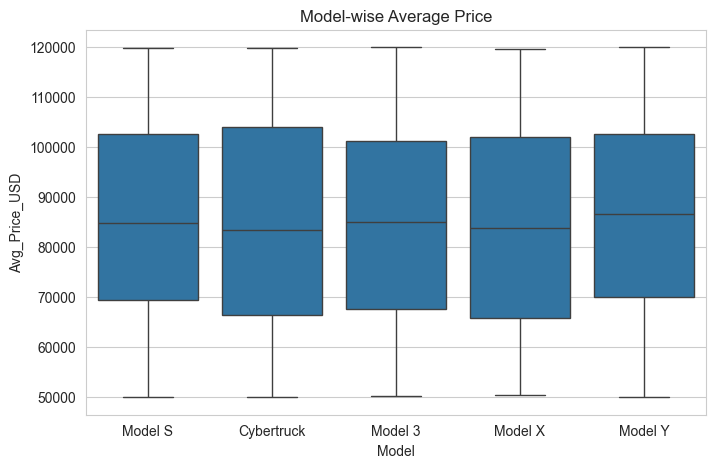

In [25]:

plt.figure(figsize=(8,5))
sns.boxplot(x='Model', y='Avg_Price_USD', data=df)
plt.title('Model-wise Average Price')
plt.show()


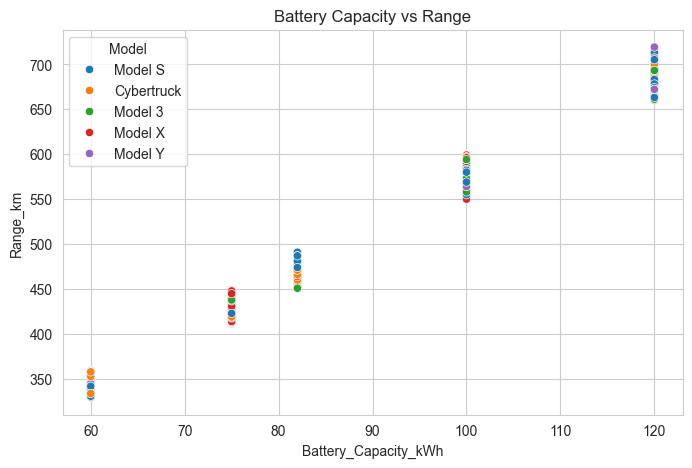

In [26]:

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Battery_Capacity_kWh',
    y='Range_km',
    hue='Model',
    data=df
)
plt.title('Battery Capacity vs Range')
plt.show()


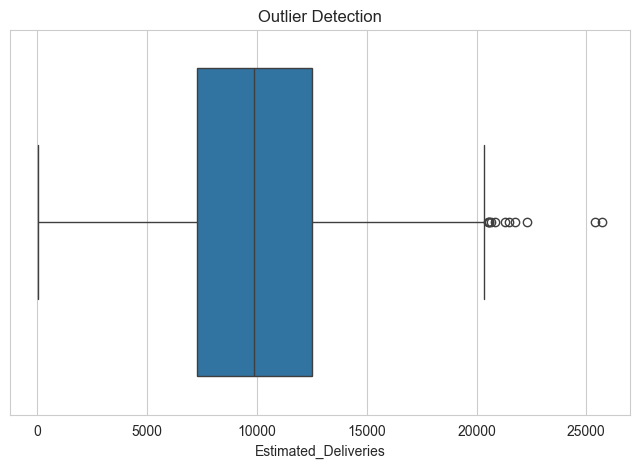

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Estimated_Deliveries"]
)

plt.title("Outlier Detection")
plt.show()

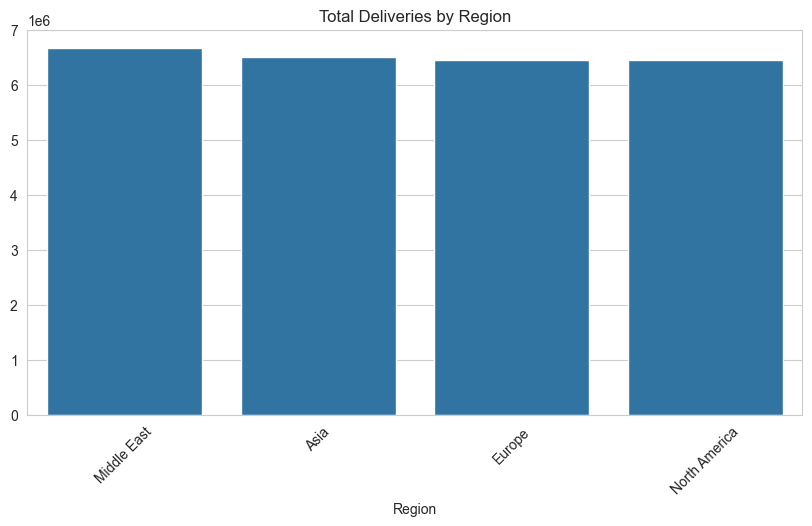

In [28]:
region_sales = (
    df.groupby("Region")
    ["Estimated_Deliveries"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Total Deliveries by Region")
plt.xticks(rotation=45)

plt.show()

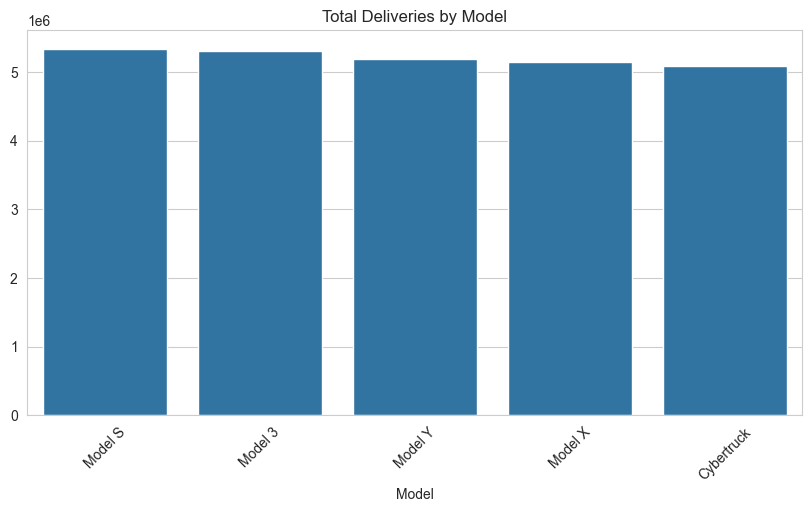

In [29]:
model_sales = (
    df.groupby("Model")
    ["Estimated_Deliveries"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=model_sales.index,
    y=model_sales.values
)

plt.title("Total Deliveries by Model")
plt.xticks(rotation=45)

plt.show()

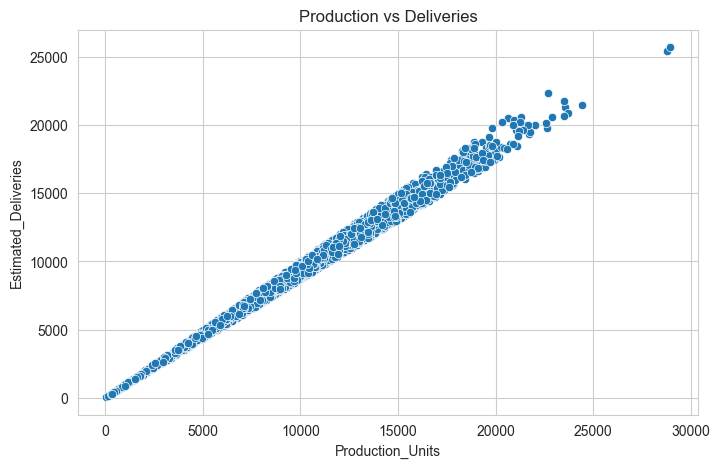

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production vs Deliveries")
plt.show()

# Time Series Analysis

To analyze delivery trends over time, deliveries are aggregated at the monthly level.

This prevents duplicate dates from creating misleading visualizations.

In [31]:
monthly_delivery = (
    df.groupby("Date")
    ["Estimated_Deliveries"]
    .sum()
    .reset_index()
)

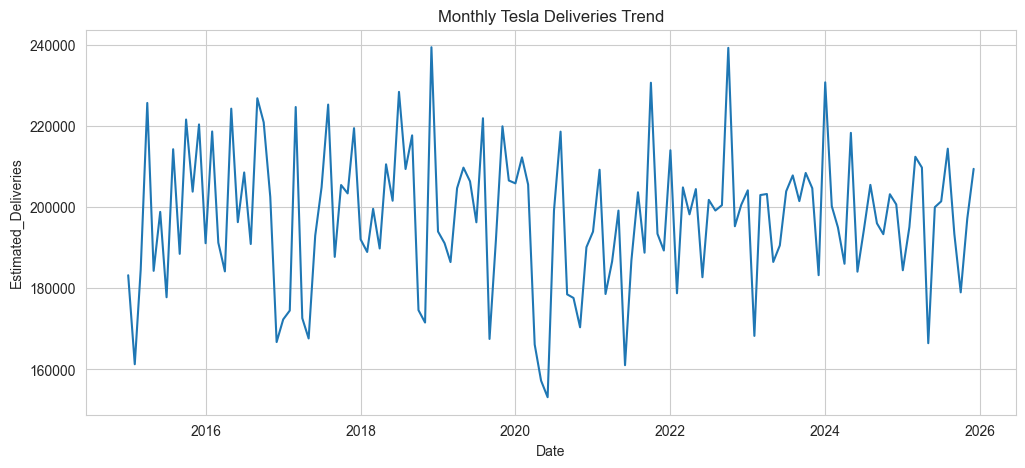

In [32]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_delivery,
    x="Date",
    y="Estimated_Deliveries"
)

plt.title("Monthly Tesla Deliveries Trend")

plt.show()

In [33]:
monthly_delivery["Rolling_Mean"] = (
    monthly_delivery["Estimated_Deliveries"]
    .rolling(12)
    .mean()
)

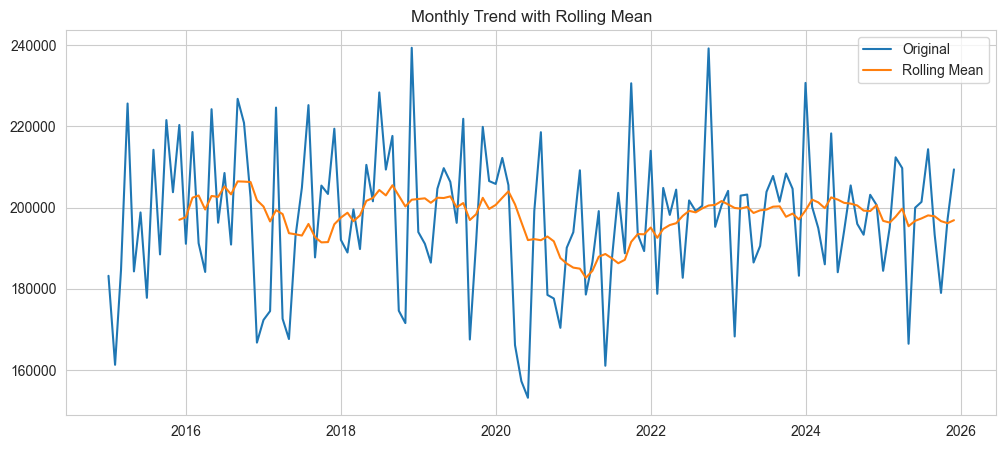

In [34]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_delivery["Date"],
    monthly_delivery["Estimated_Deliveries"],
    label="Original"
)

plt.plot(
    monthly_delivery["Date"],
    monthly_delivery["Rolling_Mean"],
    label="Rolling Mean"
)

plt.legend()

plt.title("Monthly Trend with Rolling Mean")

plt.show()

# Machine Learning Preparation

Preparing features and target variable for predictive modeling.

In [35]:
features = [
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations',
    'Quarter',
    'Efficiency',
    'Lag_1',
    'Lag_3',
    'Rolling_Mean_3',
    'Region',
    'Model',
    'Source_Type'
]

target = "Estimated_Deliveries"

In [36]:
X = df[features]
y = df[target]

In [37]:
categorical_features = [
    'Region',
    'Model',
    'Source_Type'
]

numeric_features = [
    col for col in features
    if col not in categorical_features
]

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [39]:
split_index = int(len(df)*0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [40]:
#(Linear Regression)
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [41]:
pred_lr = linear_model.predict(X_test)

In [42]:
#Ridge
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_model.fit(X_train,y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [43]:
pred_ridge = ridge_model.predict(X_test)

In [44]:
#lasso
lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso())
])

lasso_model.fit(X_train,y_train)

pred_lasso = lasso_model.predict(X_test)

In [45]:
#(Random Forest)
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42
    ))
])

rf_model.fit(X_train,y_train)

pred_rf = rf_model.predict(X_test)

In [46]:
def evaluate(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true,y_pred)
    )

    mae = mean_absolute_error(
        y_true,y_pred
    )

    r2 = r2_score(
        y_true,y_pred
    )

    return rmse,mae,r2

In [47]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Random Forest"
    ],
    "RMSE":[
        evaluate(y_test,pred_lr)[0],
        evaluate(y_test,pred_ridge)[0],
        evaluate(y_test,pred_lasso)[0],
        evaluate(y_test,pred_rf)[0]
    ],
    "MAE":[
        evaluate(y_test,pred_lr)[1],
        evaluate(y_test,pred_ridge)[1],
        evaluate(y_test,pred_lasso)[1],
        evaluate(y_test,pred_rf)[1]
    ],
    "R2":[
        evaluate(y_test,pred_lr)[2],
        evaluate(y_test,pred_ridge)[2],
        evaluate(y_test,pred_lasso)[2],
        evaluate(y_test,pred_rf)[2]
    ]
})

results.sort_values(
    "R2",
    ascending=False
)

,Model,RMSE,MAE,R2
3,Random Forest,106.833156,67.181371,0.999256
1,Ridge,149.340511,105.025306,0.998547
0,Linear Regression,149.823553,105.245045,0.998538
2,Lasso,149.914830,105.240724,0.998536


(Hyperparameter Tuning)

In [48]:
param_grid = {
    "model__n_estimators":[100,200],
    "model__max_depth":[5,10,None]
}

grid = GridSearchCV(
    rf_model,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train,y_train)

grid.best_params_
print("Best Score:", grid.best_score_)

Best Score: 0.9976809168683268


In [49]:
best_model = grid.best_estimator_

predictions = best_model.predict(X_test)

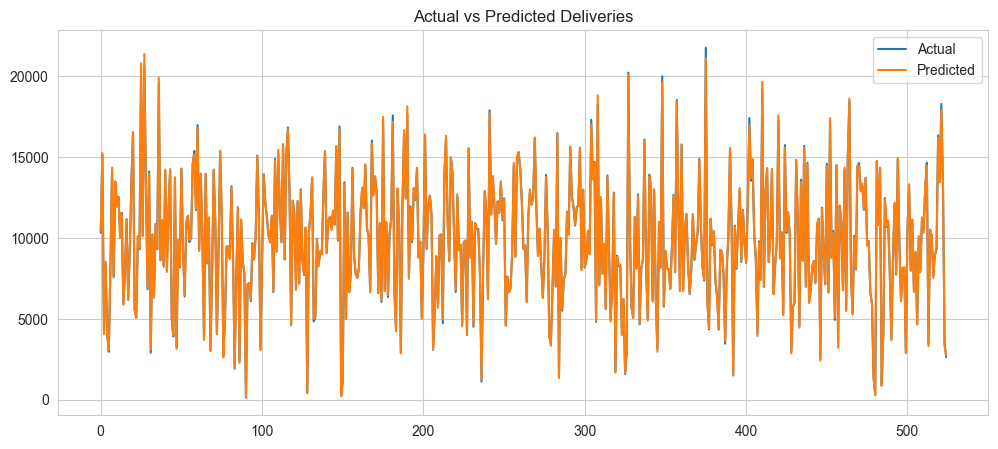

In [50]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.legend()

plt.title(
    "Actual vs Predicted Deliveries"
)

plt.show()

# Conclusion

The project successfully developed a complete Machine Learning pipeline for Tesla delivery prediction.

Key achievements:

- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Time Series Trend Analysis
- Machine Learning Pipelines
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regression
- Hyperparameter Tuning
- Model Evaluation

Among all models, the best-performing model was selected using RMSE, MAE, and R² metrics.

The analysis demonstrates how production, infrastructure, and historical patterns influence Tesla deliveries.